# Setup

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import date, timedelta


import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.stats import norm


sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 6))

In [2]:
tickers = ['MAT','DIS','KO', 'NVDA','PFE', "AAPL", "META", "TSLA", "^GSPC","MSFT",]
rf = .06

yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-05-16


# Data

In [3]:
%%time
start_date = "2018-01-01"
print(f"The number of stock to download are {len(tickers)}")
all_data = yf.download(tickers, start_date, yesterday)
price_data =  all_data["Adj Close"].copy() # pd.DataFrame({ticker: data['Adj Close'] for ticker, data in all_data.items()})
price_data.info()

The number of stock to download are 10
[*********************100%***********************]  10 of 10 completed
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1351 entries, 2018-01-02 00:00:00-05:00 to 2023-05-15 00:00:00-04:00
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1351 non-null   float64
 1   DIS     1351 non-null   float64
 2   KO      1351 non-null   float64
 3   MAT     1351 non-null   float64
 4   META    1351 non-null   float64
 5   MSFT    1351 non-null   float64
 6   NVDA    1351 non-null   float64
 7   PFE     1351 non-null   float64
 8   TSLA    1351 non-null   float64
 9   ^GSPC   1351 non-null   float64
dtypes: float64(10)
memory usage: 116.1 KB
CPU times: user 245 ms, sys: 50.1 ms, total: 295 ms
Wall time: 1.22 s


In [4]:
price_data.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-02 00:00:00-05:00,40.831585,108.726059,38.548210,16.020000,181.419998,80.738174,49.326294,28.254053,21.368668,2695.810059
2018-01-03 00:00:00-05:00,40.824482,109.192848,38.463562,16.139999,184.669998,81.113907,52.572655,28.463394,21.150000,2713.060059
2018-01-04 00:00:00-05:00,41.014099,109.144241,39.005299,15.910000,184.330002,81.827827,52.849766,28.525419,20.974667,2723.989990
2018-01-05 00:00:00-05:00,41.481064,108.551003,38.996834,16.260000,186.850006,82.842346,53.297630,28.579699,21.105333,2743.149902
2018-01-08 00:00:00-05:00,41.326988,106.994995,38.937588,15.810000,188.279999,82.926880,54.930717,28.261803,22.427334,2747.709961


In [5]:
price_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1351 entries, 2018-01-02 00:00:00-05:00 to 2023-05-15 00:00:00-04:00
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1351 non-null   float64
 1   DIS     1351 non-null   float64
 2   KO      1351 non-null   float64
 3   MAT     1351 non-null   float64
 4   META    1351 non-null   float64
 5   MSFT    1351 non-null   float64
 6   NVDA    1351 non-null   float64
 7   PFE     1351 non-null   float64
 8   TSLA    1351 non-null   float64
 9   ^GSPC   1351 non-null   float64
dtypes: float64(10)
memory usage: 116.1 KB


In [6]:
price_data.isna().sum()

AAPL     0
DIS      0
KO       0
MAT      0
META     0
MSFT     0
NVDA     0
PFE      0
TSLA     0
^GSPC    0
dtype: int64

In [7]:
price_data.reset_index().Date.agg([min,max])

min   2018-01-02 00:00:00-05:00
max   2023-05-15 00:00:00-04:00
Name: Date, dtype: datetime64[ns, America/New_York]

In [8]:
price_data.reset_index().agg([min,max])

,Date,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
min,2018-01-02 00:00:00-05:00,34.209953,84.169998,34.232876,7.230000,88.910004,79.855164,31.531855,23.970982,11.931333,2237.399902
max,2023-05-15 00:00:00-04:00,180.434296,201.910004,64.306442,26.969999,382.179993,339.075562,333.350769,58.154461,409.970001,4796.560059


In [9]:
price_data.agg([min,max]).pct_change().dropna()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
max,4.274322,1.398836,0.8785,2.73029,3.298504,3.246132,9.571873,1.426036,33.360789,1.14381


In [10]:
price_data.iloc[[0,-1]]

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-02 00:00:00-05:00,40.831585,108.726059,38.548210,16.020000,181.419998,80.738174,49.326294,28.254053,21.368668,2695.810059
2023-05-15 00:00:00-04:00,172.070007,92.860001,63.939999,19.200001,238.860001,309.459991,289.529999,37.160000,166.350006,4136.279785


In [11]:
100000 * (164.309998/21.368668)

768929.5280360947

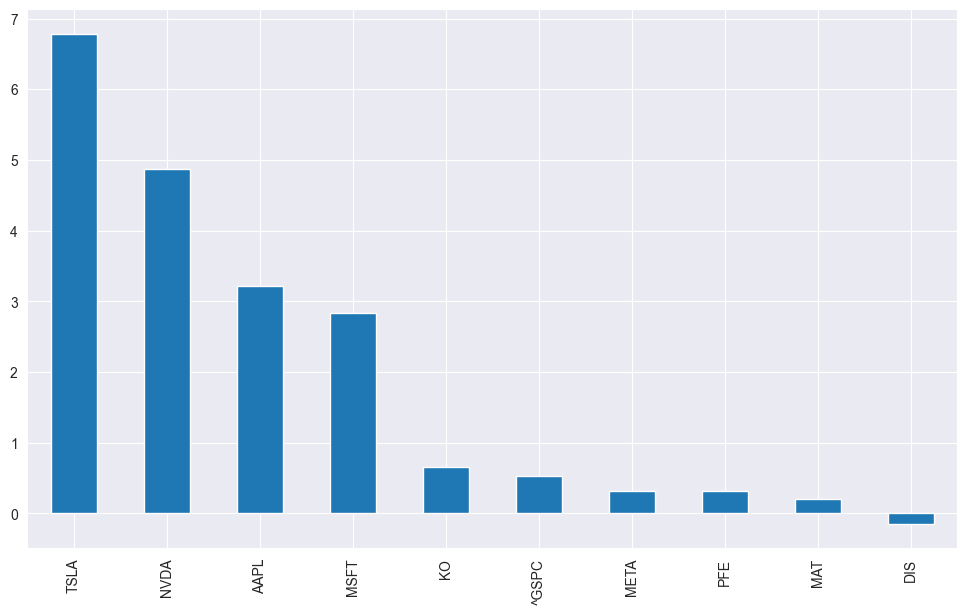

In [12]:
price_data.iloc[[0,-1]].pct_change().dropna().reset_index(drop=True).T.sort_values(
    by=0,
    ascending=False
).plot(
    kind='bar',
    legend=False,
    figsize=(12,7)
);

In [13]:
price_data.iloc[[0,-1]].pct_change().dropna().reset_index(drop=True).T.sort_values(
    by=0,
    ascending=False
)

,0
TSLA,6.784763
NVDA,4.869689
AAPL,3.214140
MSFT,2.832883
KO,0.658702
^GSPC,0.534337
META,0.316613
PFE,0.315210
MAT,0.198502
DIS,-0.145927


<AxesSubplot: xlabel='Date'>

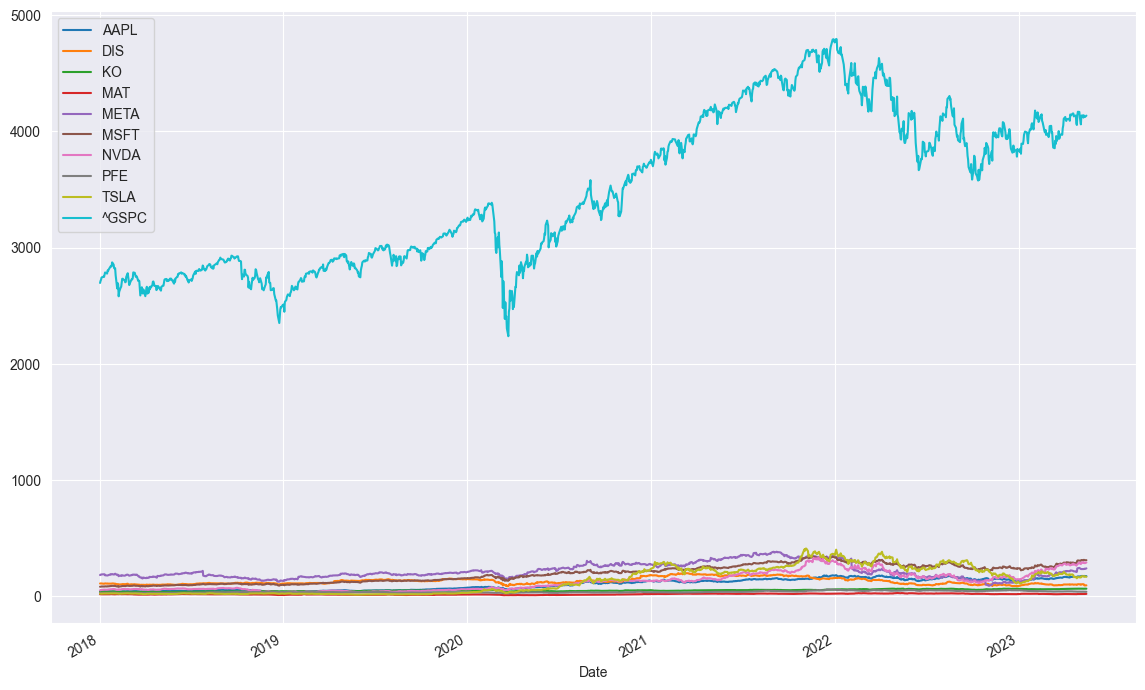

In [14]:
price_data.plot(figsize=(14,9))

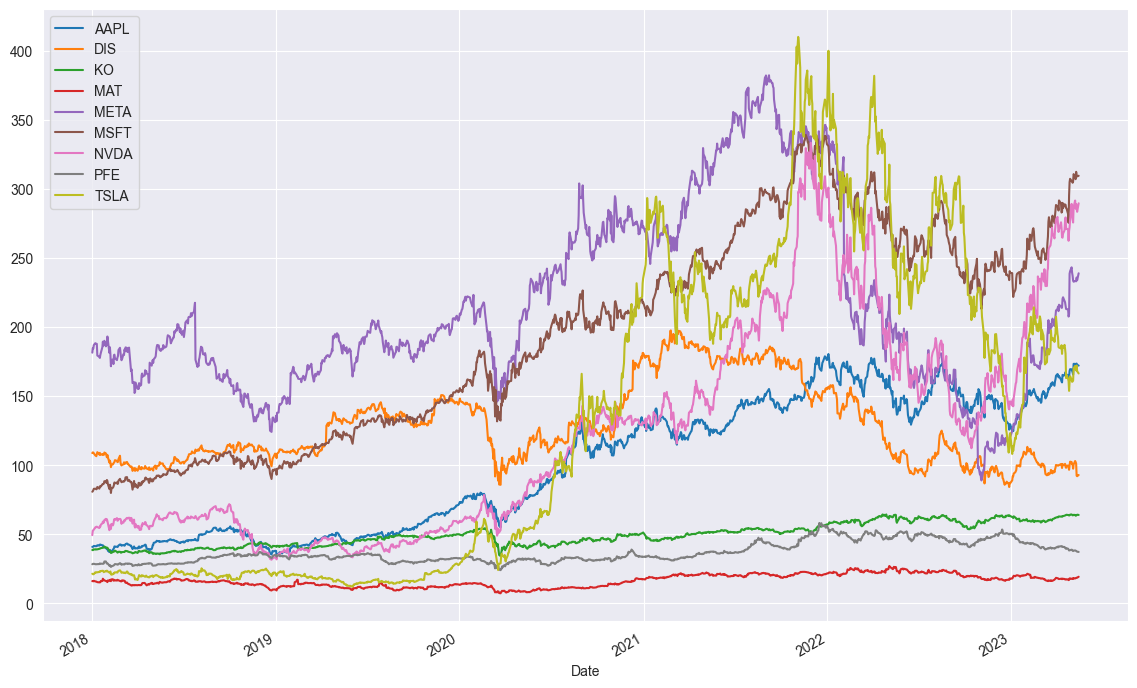

In [15]:
price_data.drop(columns='^GSPC').plot(figsize=(14,9));

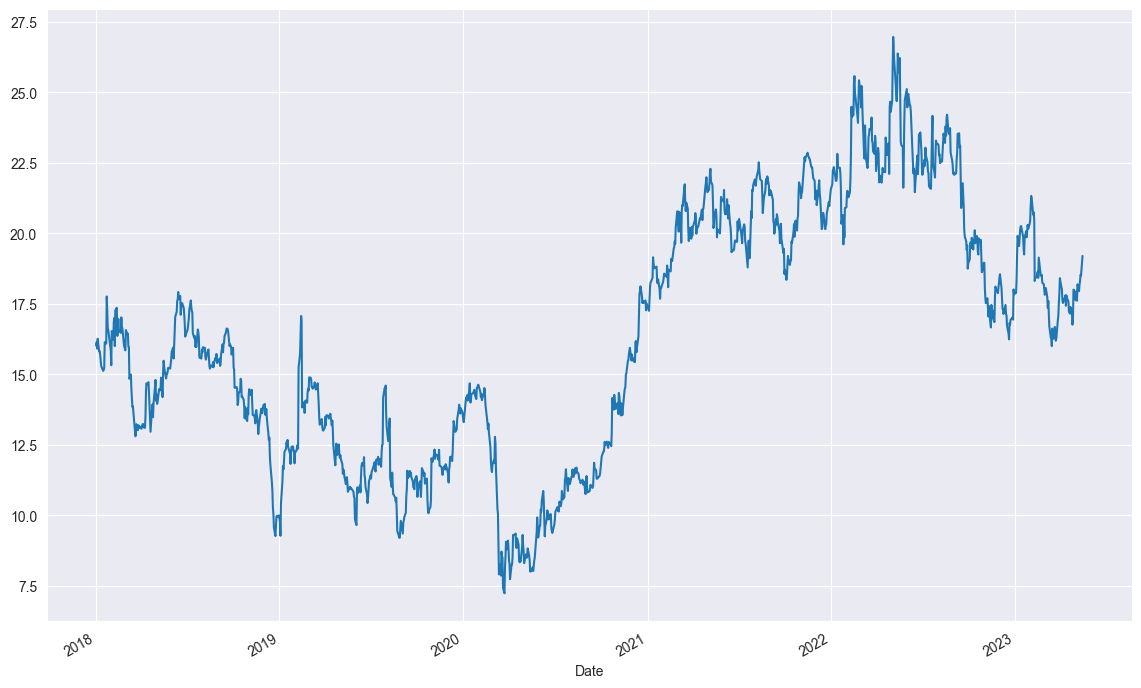

In [16]:
price_data.MAT.plot(figsize=(14,9));

In [17]:
df_log = np.log(price_data.pct_change().dropna() +1)
df_log.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-03 00:00:00-05:00,-0.000174,0.004284,-0.002198,0.007463,0.017756,0.004643,0.063739,0.007382,-0.010286,0.006378
2018-01-04 00:00:00-05:00,0.004634,-0.000445,0.013986,-0.014353,-0.001843,0.008763,0.005257,0.002177,-0.008325,0.004021
2018-01-05 00:00:00-05:00,0.011321,-0.005450,-0.000217,0.021760,0.013579,0.012322,0.008439,0.001901,0.006210,0.007009
2018-01-08 00:00:00-05:00,-0.003721,-0.014438,-0.001520,-0.028065,0.007624,0.001020,0.030181,-0.011185,0.060755,0.001661
2018-01-09 00:00:00-05:00,-0.000114,-0.000727,0.004987,0.000632,-0.002180,-0.000680,-0.000271,-0.001098,-0.008118,0.001302


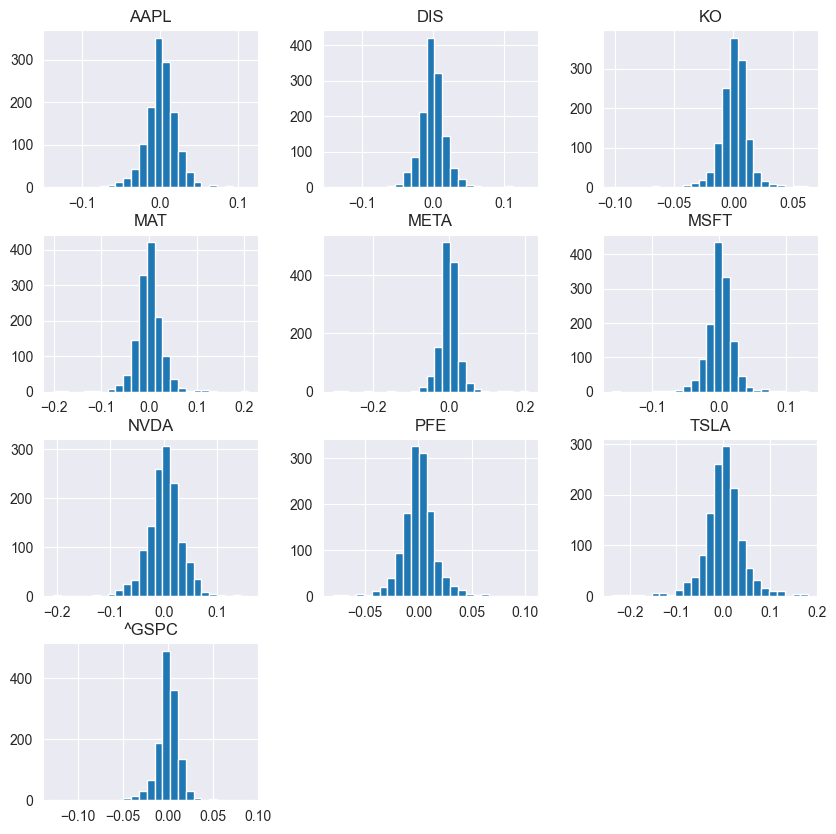

In [18]:
df_log.hist(
    figsize=(10,10),
    bins=25
);

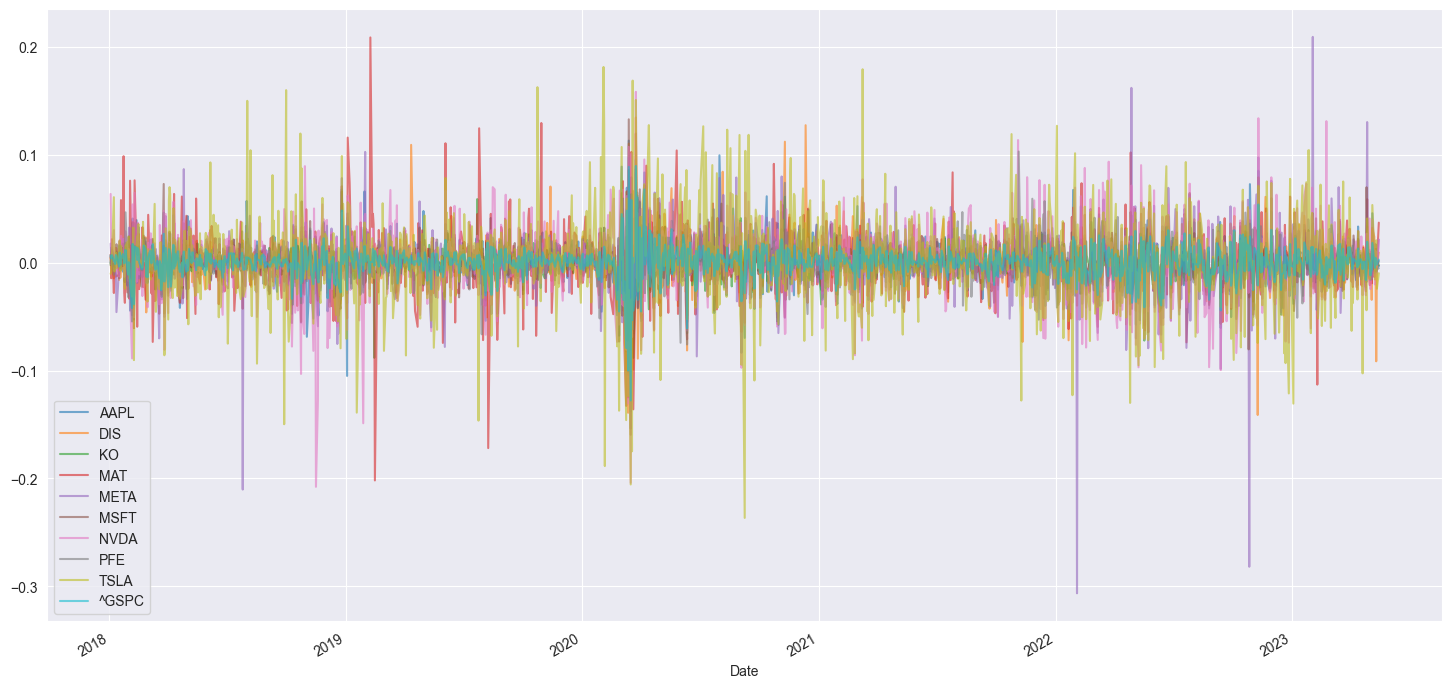

In [19]:
df_log.plot(figsize=(18,9), alpha=0.6);

# Estimadores

In [20]:
avg_daily = df_log.mean()
std_daily = df_log.std()
cov_daily = df_log.cov()

avg_ann = avg_daily * 252
std_ann = std_daily * (252**(1/2))
cov_ann = cov_daily * 252

In [21]:
avg_ann.sort_values()

DIS     -0.029445
MAT      0.033800
PFE      0.051146
META     0.051345
^GSPC    0.079912
KO       0.094460
MSFT     0.250809
AAPL     0.268510
NVDA     0.330363
TSLA     0.383071
dtype: float64

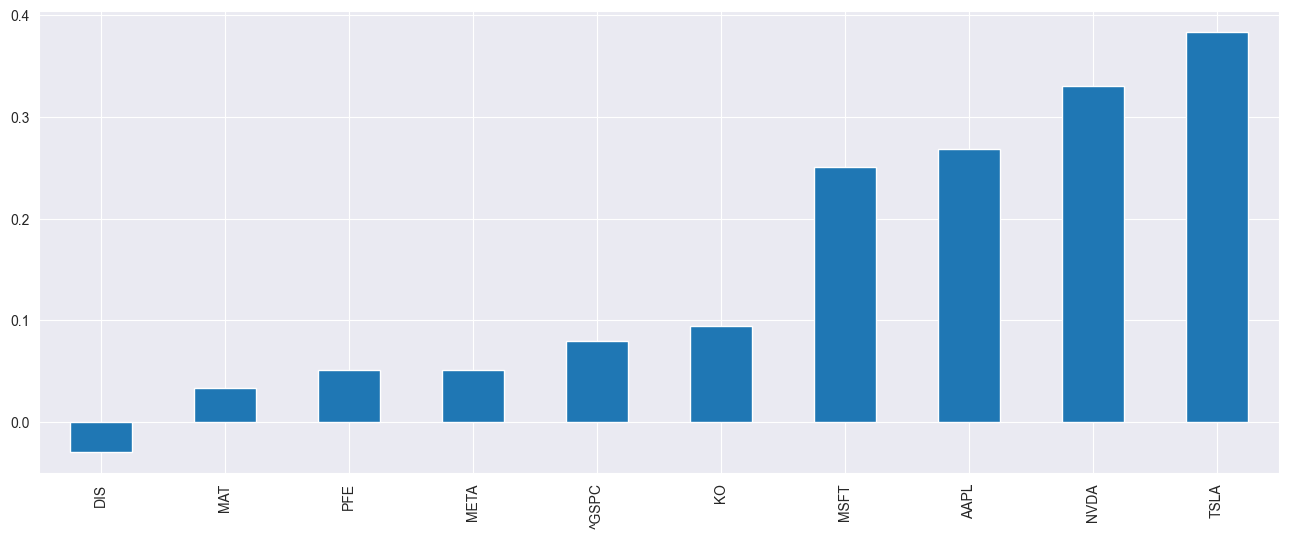

In [22]:
avg_ann.sort_values().plot(
    kind='bar'
);

In [23]:
cov_ann

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
AAPL,0.108356,0.052144,0.029631,0.052286,0.084018,0.077742,0.112585,0.029755,0.102366,0.056996
DIS,0.052144,0.105552,0.032328,0.055344,0.059940,0.052410,0.074525,0.024250,0.068747,0.048139
KO,0.029631,0.032328,0.044945,0.031512,0.022716,0.029847,0.030464,0.024735,0.027426,0.029566
MAT,0.052286,0.055344,0.031512,0.198795,0.060180,0.049634,0.078013,0.024871,0.069631,0.047512
META,0.084018,0.059940,0.022716,0.060180,0.201731,0.084341,0.126621,0.027582,0.098196,0.059615
MSFT,0.077742,0.052410,0.029847,0.049634,0.084341,0.095858,0.114211,0.031030,0.092424,0.056337
NVDA,0.112585,0.074525,0.030464,0.078013,0.126621,0.114211,0.269553,0.035245,0.164641,0.080855
PFE,0.029755,0.024250,0.024735,0.024871,0.027582,0.031030,0.035245,0.066361,0.018631,0.028283
TSLA,0.102366,0.068747,0.027426,0.069631,0.098196,0.092424,0.164641,0.018631,0.426360,0.068706
^GSPC,0.056996,0.048139,0.029566,0.047512,0.059615,0.056337,0.080855,0.028283,0.068706,0.046542


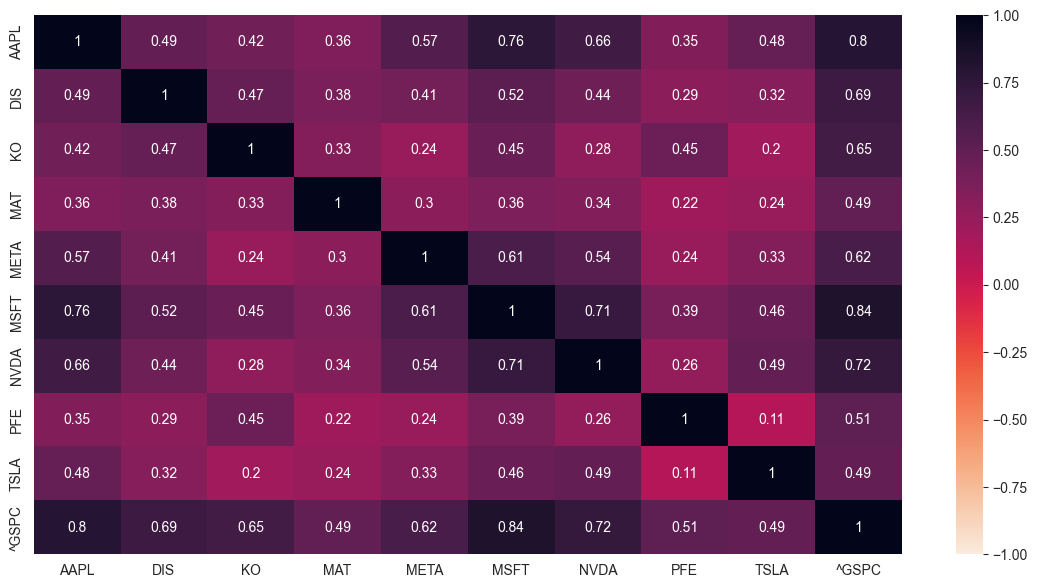

In [24]:
fig, ax = plt.subplots(figsize=(14,7))    
sns.heatmap(
    df_log.corr(method='pearson'), 
    vmin=-1, 
    vmax=1,
    annot=True,cmap="rocket_r",
    ax=ax
)
plt.show()

In [25]:
df_log.var() * 252

AAPL     0.108356
DIS      0.105552
KO       0.044945
MAT      0.198795
META     0.201731
MSFT     0.095858
NVDA     0.269553
PFE      0.066361
TSLA     0.426360
^GSPC    0.046542
dtype: float64

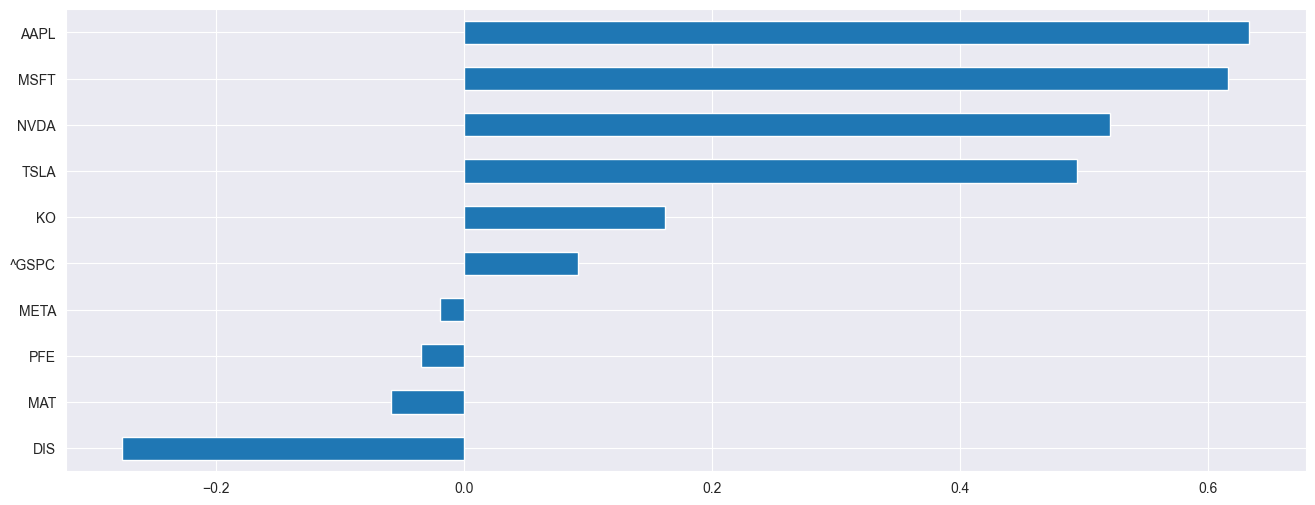

In [26]:
df_parameters_stocks = pd.concat(
    [
        avg_ann,
        (df_log.var() * 252) ** (1/2)
    ],
    axis = 1
)

df_parameters_stocks.columns = ['return', 'volatility']

df_parameters_stocks['sharpe_ratio'] = (df_parameters_stocks['return'] - rf) / df_parameters_stocks.volatility

df_parameters_stocks['sharpe_ratio'].sort_values().plot(kind='barh');


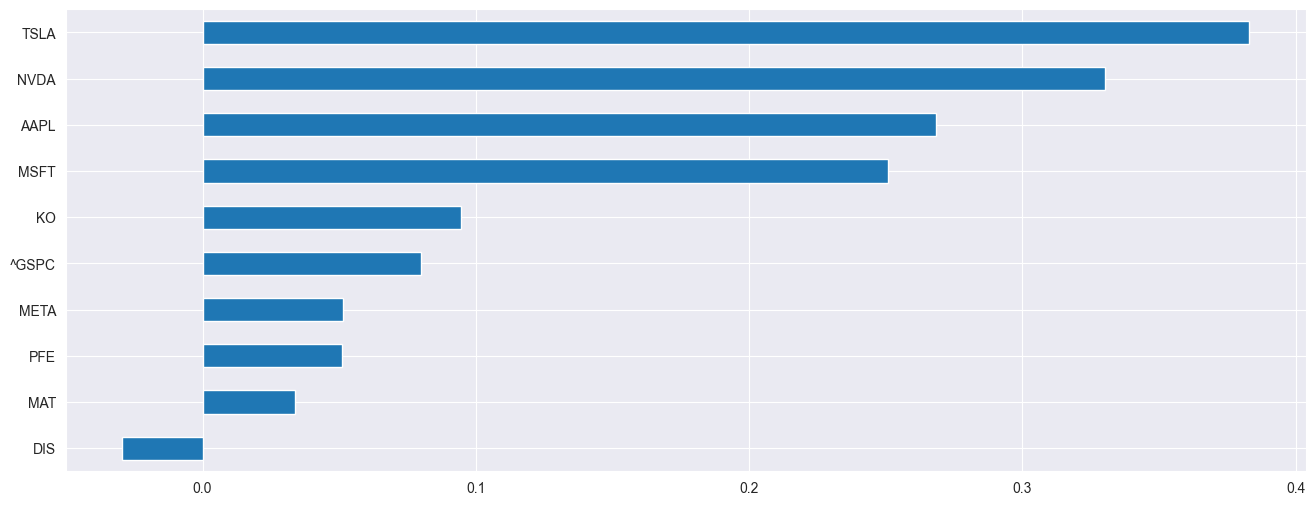

In [27]:
df_parameters_stocks['return'].sort_values().plot(kind='barh');

In [28]:
df_parameters_stocks

,return,volatility,sharpe_ratio
AAPL,0.268510,0.329175,0.633432
DIS,-0.029445,0.324888,-0.275309
KO,0.094460,0.212002,0.162546
MAT,0.033800,0.445864,-0.058762
META,0.051345,0.449145,-0.019270
MSFT,0.250809,0.309609,0.616290
NVDA,0.330363,0.519185,0.520745
PFE,0.051146,0.257606,-0.034371
TSLA,0.383071,0.652963,0.494778
^GSPC,0.079912,0.215737,0.092296


# Simulated portfolios

In [29]:
%%time
port_returns = []
port_volatility = []
lst_weights = []

num_assets = len(tickers)
num_portfolios = 50000

for single_portfolio in range(num_portfolios):

  weights = np.array([random.randint(-1000,1000) for x in range(num_assets)], dtype=float)
  weights = weights / np.sum(weights)
  
  returns = np.dot(weights, avg_ann)
  volatility = np.sqrt(np.dot(weights.T, np.dot(cov_ann,weights)))
  if volatility <= .9:
    port_returns.append(returns)
    port_volatility.append(volatility)
    lst_weights.append([round(weight,2) for weight in weights])


df_portfolios = pd.DataFrame(
    {
        'return':port_returns,
        'volatility':port_volatility,
        'weights':lst_weights
    }
)
df_portfolios.head()


<timed exec>:11: RuntimeWarning: divide by zero encountered in divide


CPU times: user 1.96 s, sys: 66 ms, total: 2.02 s
Wall time: 1.68 s


,return,volatility,weights
0,0.004895,0.281741,"[0.32, 0.47, 0.02, -0.05, 0.24, 0.13, -0.11, 0..."
1,0.230897,0.472801,"[-0.32, 0.44, 0.03, -0.04, -0.3, -0.08, 0.41, ..."
2,0.149590,0.250991,"[0.17, 0.1, 0.13, 0.04, 0.06, -0.01, 0.04, 0.1..."
3,-0.217877,0.640942,"[0.84, 0.87, -0.16, 0.74, -0.6, -0.42, -0.14, ..."
4,0.193006,0.366565,"[0.06, 0.18, -0.08, 0.24, 0.01, -0.02, 0.23, -..."


In [30]:
df_portfolios['return'].agg(['mean', 'std'])

mean    0.142356
std     0.181644
Name: return, dtype: float64

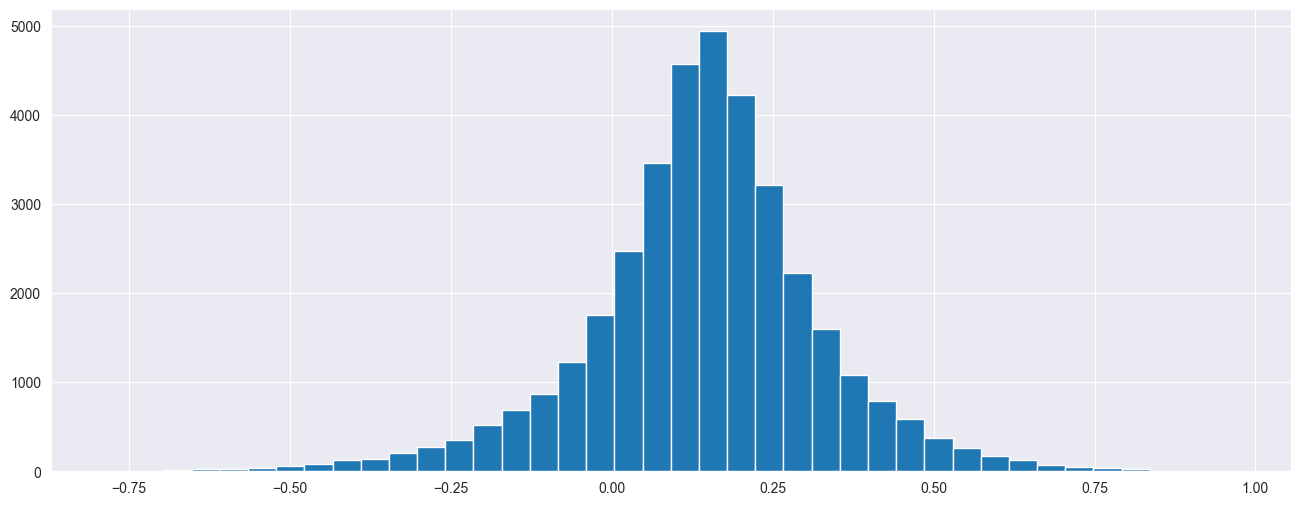

In [31]:
df_portfolios['return'].hist(bins=40);

In [32]:
df_portfolios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36674 entries, 0 to 36673
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   return      36674 non-null  float64
 1   volatility  36674 non-null  float64
 2   weights     36674 non-null  object 
dtypes: float64(2), object(1)
memory usage: 859.7+ KB


In [33]:
avg_ann.head()

AAPL    0.268510
DIS    -0.029445
KO      0.094460
MAT     0.033800
META    0.051345
dtype: float64

In [34]:
avg_ann.loc['MAT']

0.03380017173034902

In [35]:
std_ann

AAPL     0.329175
DIS      0.324888
KO       0.212002
MAT      0.445864
META     0.449145
MSFT     0.309609
NVDA     0.519185
PFE      0.257606
TSLA     0.652963
^GSPC    0.215737
dtype: float64

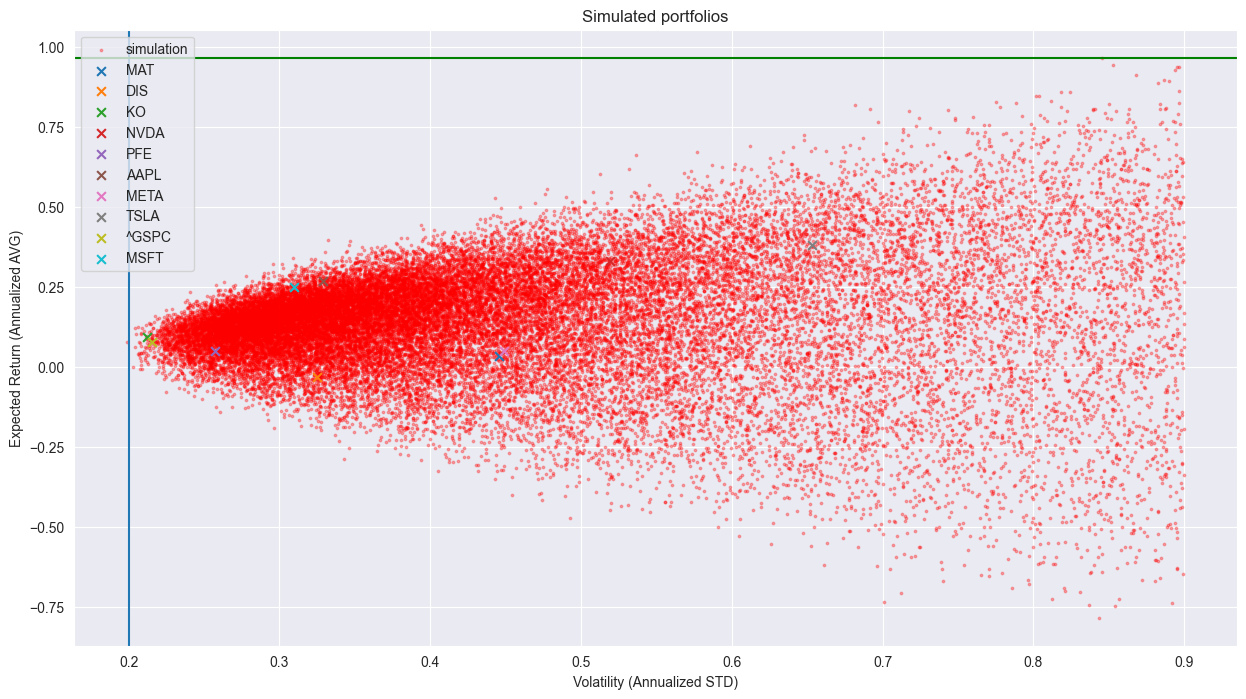

In [36]:
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)

ax1.scatter(df_portfolios['volatility'], df_portfolios['return'], s=3, c='r', marker='o', label='simulation', alpha=.3)

for stock in tickers:
  ax1.scatter(std_ann.loc[stock], avg_ann.loc[stock], s=40, marker='x', label=stock)

plt.xlabel('Volatility (Annualized STD)')
plt.ylabel('Expected Return (Annualized AVG)')
plt.title('Simulated portfolios')

plt.legend(loc='upper left')
plt.axvline(.2)
plt.axhline(df_portfolios['return'].max(), color='green')
plt.show();

In [37]:
df_portfolios.iloc[df_portfolios['return'].idxmax()]

return                                                 0.967203
volatility                                             0.845304
weights       [1.61, -1.96, 1.86, 0.51, 0.13, 0.61, 0.54, -0...
Name: 6127, dtype: object

In [38]:
df_portfolios.iloc[df_portfolios['volatility'].idxmin()]

return                                                 0.079622
volatility                                             0.199105
weights       [0.13, -0.0, 0.3, 0.02, 0.03, 0.18, -0.26, 0.2...
Name: 6634, dtype: object

In [39]:
tickers

['MAT', 'DIS', 'KO', 'NVDA', 'PFE', 'AAPL', 'META', 'TSLA', '^GSPC', 'MSFT']

# Minimum variance portfolio (MVP)

In [40]:
def get_mvp_portfolio(Cov):
  inv_Cov = np.linalg.inv(Cov)
  M_1 = np.zeros((Cov.shape[0],)) + 1 

  num = inv_Cov @ M_1
  den = M_1.T @ inv_Cov @ M_1

  W_mvp = num /den

  return W_mvp

In [41]:
W_mvp = get_mvp_portfolio(cov_ann)
print(W_mvp)

[-7.23116351e-02 -4.90198953e-02  2.97802023e-01 -1.17174762e-02
  8.94876562e-03 -9.83495331e-02 -1.06732082e-01  1.73870946e-01
  2.04075850e-05  8.57488479e-01]


In [42]:
return_mvp = W_mvp.T @ avg_ann
volatility_mvp = (W_mvp.T @ cov_ann @ W_mvp)**0.5

print(f"Return mvp portfolio: {return_mvp}")
print(f"Volatility mvp portfolio: {volatility_mvp}")

Return mvp portfolio: 0.02771744971394704
Volatility mvp portfolio: 0.18154463296768694


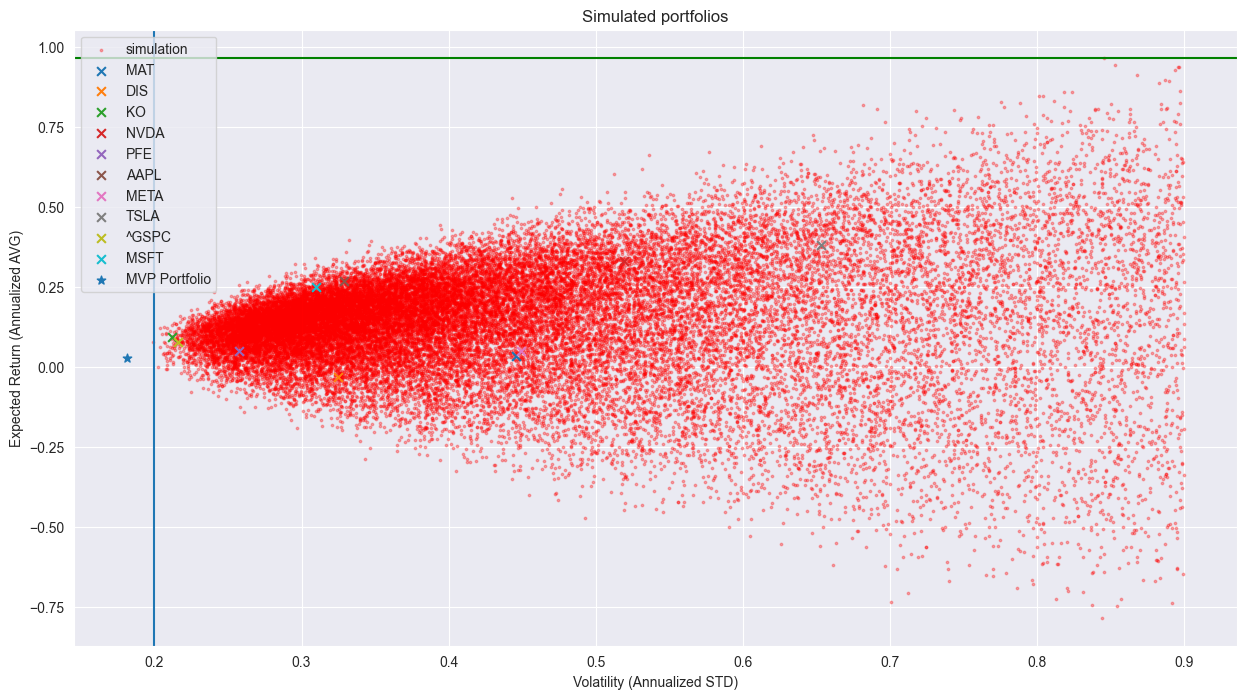

In [43]:
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)

ax1.scatter(df_portfolios['volatility'], df_portfolios['return'], s=3, c='r', marker='o', label='simulation', alpha=.3)

for stock in tickers:
  ax1.scatter(std_ann.loc[stock], avg_ann.loc[stock], s=40, marker='x', label=stock)

ax1.scatter(volatility_mvp, return_mvp, s=40, marker='*', label='MVP Portfolio')

plt.xlabel('Volatility (Annualized STD)')
plt.ylabel('Expected Return (Annualized AVG)')
plt.title('Simulated portfolios')

plt.legend(loc='upper left')
plt.axvline(.2)
plt.axhline(df_portfolios['return'].max(), color='green')
plt.show();

# Efficient frontier

In [44]:
np.zeros((len(cov_ann), )) + 1 

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [45]:
def get_efficient_frontier(Cov, E, rp):
  '''
  Calculate efficient frontier given the following parameters: 
    - Cov: Covariance matrix
    - E: Vector of estimated returns
    - rp: Expected return of portfolio
  '''
  M_1 = np.zeros((len(Cov), )) + 1 
  inv_Cov = np.linalg.inv(Cov)
  A = (M_1.T @ inv_Cov @ E)
  B = (E.T @ inv_Cov @ E)
  C = (M_1.T @ inv_Cov @ M_1)
  D = B * C - A**2

  g = (1/D) * ((B * inv_Cov @ M_1) - (A * inv_Cov @ E ))
  h = (1/D) * ((C * inv_Cov @ E) - (A * inv_Cov @ M_1 ))

  W_efficient_frontier = g + (h * rp)

  return W_efficient_frontier

In [46]:
get_efficient_frontier(cov_ann, avg_ann, 0.25)

array([ 0.29727147, -0.14665421,  0.71658049,  0.0015116 , -0.08342559,
        0.39770895,  0.01953803,  0.20703787,  0.06050431, -0.47007292])

In [47]:
W_15_mvp = get_efficient_frontier(cov_ann, avg_ann, 0.25)
return_15_mvp = W_15_mvp.T @ avg_ann
volatility_15_mvp = (W_15_mvp.T @ cov_ann @ W_15_mvp)**0.5

print(f"Return mvp portfolio: {return_15_mvp}")
print(f"Volatility mvp portfolio: {volatility_15_mvp}")

Return mvp portfolio: 0.24999999999999992
Volatility mvp portfolio: 0.23591778772150823


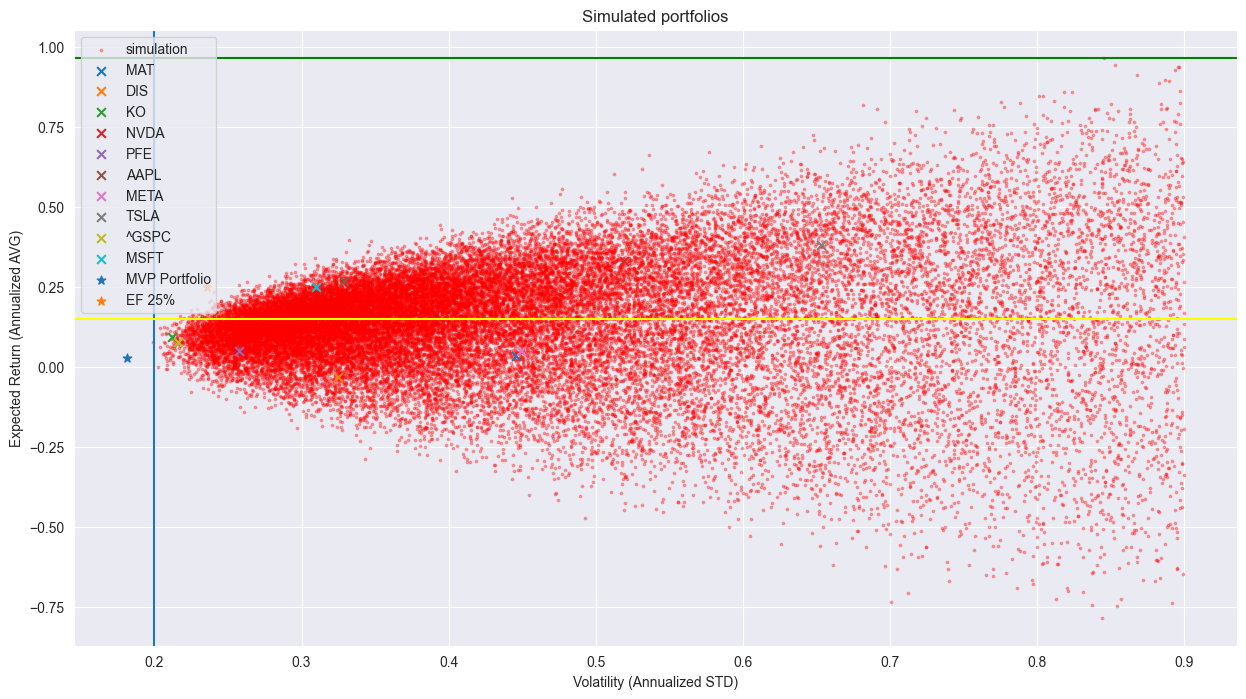

In [48]:
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)
expected_return = .25

ax1.scatter(df_portfolios['volatility'], df_portfolios['return'], s=3, c='r', marker='o', label='simulation', alpha=.3)

for stock in tickers:
  ax1.scatter(std_ann.loc[stock], avg_ann.loc[stock], s=40, marker='x', label=stock)

ax1.scatter(volatility_mvp, return_mvp, s=40, marker='*', label='MVP Portfolio')
ax1.scatter(volatility_15_mvp, return_15_mvp, s=40, marker='*', label=f'EF {expected_return:.0%}')

plt.xlabel('Volatility (Annualized STD)')
plt.ylabel('Expected Return (Annualized AVG)')
plt.title('Simulated portfolios')

plt.legend(loc='upper left')
plt.axvline(.2)
plt.axhline(df_portfolios['return'].max(), color='green')
plt.axhline(.15, color='yellow')
plt.show();

In [49]:
n_points = 100
max_return = 1.5
def optimal_weights(n_points, E, cov, r_max):
  w_mvp = get_mvp_portfolio(cov)
  r_min = w_mvp.T @ E
  expected_returns = np.linspace(r_min, r_max, n_points)
  weights = [get_efficient_frontier(cov, E, rp) for rp in expected_returns]
  return weights

weights_ef = optimal_weights(n_points, avg_ann, cov_ann, max_return)
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []
for w in weights_ef:
  returns = np.dot(w, avg_ann)
  volatility = np.sqrt(np.dot(w.T, np.dot(cov_ann, w)))

  portfolio_returns.append(returns)
  portfolio_volatility.append(volatility)
  portfolio_weights.append([round(x,2) for x in w])

df_ef = pd.DataFrame(
    {
        'return':portfolio_returns,
        'volatility':portfolio_volatility,
        'weights': portfolio_weights
    }
)

df_ef.head()


,return,volatility,weights
0,0.027717,0.181545,"[-0.07, -0.05, 0.3, -0.01, 0.01, -0.1, -0.11, ..."
1,0.042589,0.181824,"[-0.05, -0.06, 0.33, -0.01, 0.0, -0.07, -0.1, ..."
2,0.057461,0.182661,"[-0.02, -0.06, 0.35, -0.01, -0.0, -0.03, -0.09..."
3,0.072332,0.184046,"[0.0, -0.07, 0.38, -0.01, -0.01, 0.0, -0.08, 0..."
4,0.087204,0.185968,"[0.03, -0.08, 0.41, -0.01, -0.02, 0.03, -0.07,..."


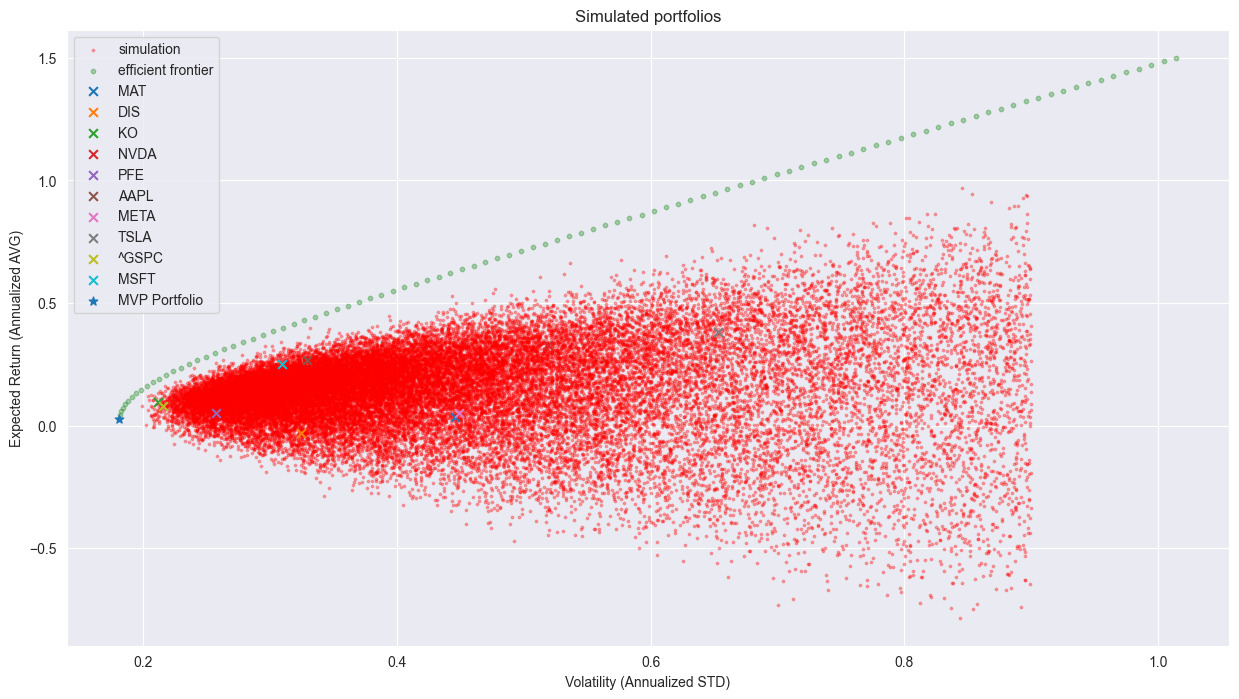

In [50]:
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)

ax1.scatter(df_portfolios['volatility'], df_portfolios['return'], s=3, c='r', marker='o', label='simulation', alpha=.3)
ax1.scatter(df_ef['volatility'], df_ef['return'], s=10, c='green', marker='o', label='efficient frontier', alpha=.3)

for stock in tickers:
  ax1.scatter(std_ann.loc[stock], avg_ann.loc[stock], s=40, marker='x', label=stock)

ax1.scatter(volatility_mvp, return_mvp, s=40, marker='*', label='MVP Portfolio')
# ax1.scatter(volatility_15_mvp, return_15_mvp, s=40, marker='*', label='EF 15%')

plt.xlabel('Volatility (Annualized STD)')
plt.ylabel('Expected Return (Annualized AVG)')
plt.title('Simulated portfolios')

plt.legend(loc='upper left')
# plt.axvline(.2)
# plt.axhline(df_portfolios['return'].max(), color='green')
# plt.axhline(.15, color='yellow')
plt.show();

# Efficient portfolio with risk free asset

In [51]:
def get_efficient_portfolio_with_rf(Cov, E, rp, rf):
  '''
  Calculate the efficient portfolio with risk free asset given the following parameters: 
    - Cov: Covariance matrix
    - E: Vector of estimated returns
    - rp: Expected return of portfolio
    - rf: Risk free asset return
  '''

  M_1 = np.zeros(len(Cov)) + 1
  inv_Cov = np.linalg.inv(Cov)

  H = (E-rf).T @ inv_Cov @ (E-rf)

  W = inv_Cov @ (E-rf)  * (rp-rf)/H
  Wf = 1 - W.sum()

  return W, Wf

In [52]:
n_points = 100
min_return = .18
max_return = 1.5
def optimal_weights_rf(n_points, E, cov, r_min, r_max,rf):
    expected_returns = np.linspace(r_min, r_max, n_points)
    weights = [get_efficient_portfolio_with_rf(cov, E, rp, rf) for rp in expected_returns]
    return weights

weights_ef_rf = optimal_weights_rf(n_points, avg_ann, cov_ann, min_return, max_return,rf)
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []
for w, wf in weights_ef_rf:
    returns = np.dot(w, avg_ann) + wf * rf
    volatility = np.sqrt(np.dot(w.T, np.dot(cov_ann, w)))

    portfolio_returns.append(returns)
    portfolio_volatility.append(volatility)
    portfolio_weights.append([round(x,2) for x in w] + [round(wf,2)])

df_ef_rf = pd.DataFrame(
    {
        'return':portfolio_returns,
        'volatility':portfolio_volatility,
        'weights': portfolio_weights
    }
)

df_ef_rf.head()

,return,volatility,weights
0,0.180000,0.080750,"[0.2, -0.05, 0.21, 0.01, -0.05, 0.27, 0.07, 0...."
1,0.193333,0.089723,"[0.22, -0.05, 0.23, 0.01, -0.06, 0.3, 0.08, 0...."
2,0.206667,0.098695,"[0.25, -0.06, 0.25, 0.01, -0.06, 0.33, 0.09, 0..."
3,0.220000,0.107667,"[0.27, -0.07, 0.28, 0.01, -0.07, 0.36, 0.1, 0...."
4,0.233333,0.116640,"[0.29, -0.07, 0.3, 0.01, -0.07, 0.39, 0.11, 0...."


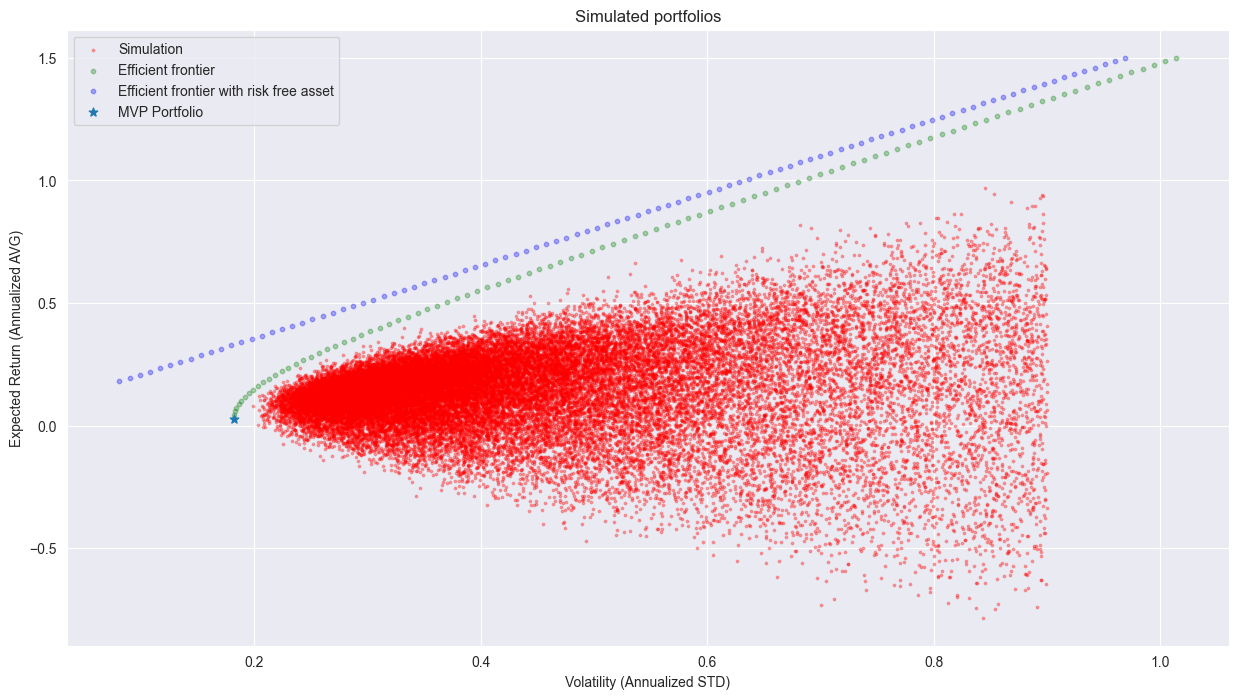

In [53]:
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)

ax1.scatter(df_portfolios['volatility'], df_portfolios['return'], s=3, c='r', marker='o', label='Simulation', alpha=.3)
ax1.scatter(df_ef['volatility'], df_ef['return'], s=10, c='green', marker='o', label='Efficient frontier', alpha=.3)
ax1.scatter(df_ef_rf['volatility'], df_ef_rf['return'], s=10, c='blue', marker='o', label='Efficient frontier with risk free asset', alpha=.3)

# for stock in tickers:
#   ax1.scatter(std_ann.loc[stock], avg_ann.loc[stock], s=40, marker='x', label=stock)

ax1.scatter(volatility_mvp, return_mvp, s=40, marker='*', label='MVP Portfolio')


plt.xlabel('Volatility (Annualized STD)')
plt.ylabel('Expected Return (Annualized AVG)')
plt.title('Simulated portfolios')

plt.legend(loc='upper left')
plt.show();

# Sharpe ratio

In [54]:
df_portfolios.head()

,return,volatility,weights
0,0.004895,0.281741,"[0.32, 0.47, 0.02, -0.05, 0.24, 0.13, -0.11, 0..."
1,0.230897,0.472801,"[-0.32, 0.44, 0.03, -0.04, -0.3, -0.08, 0.41, ..."
2,0.149590,0.250991,"[0.17, 0.1, 0.13, 0.04, 0.06, -0.01, 0.04, 0.1..."
3,-0.217877,0.640942,"[0.84, 0.87, -0.16, 0.74, -0.6, -0.42, -0.14, ..."
4,0.193006,0.366565,"[0.06, 0.18, -0.08, 0.24, 0.01, -0.02, 0.23, -..."


In [55]:
df_portfolios['sharpe_ratio'] = (df_portfolios['return'] - rf) / df_portfolios.volatility

In [56]:
df_portfolios['sharpe_ratio'].agg([min,max])

min   -1.132312
max    1.122340
Name: sharpe_ratio, dtype: float64

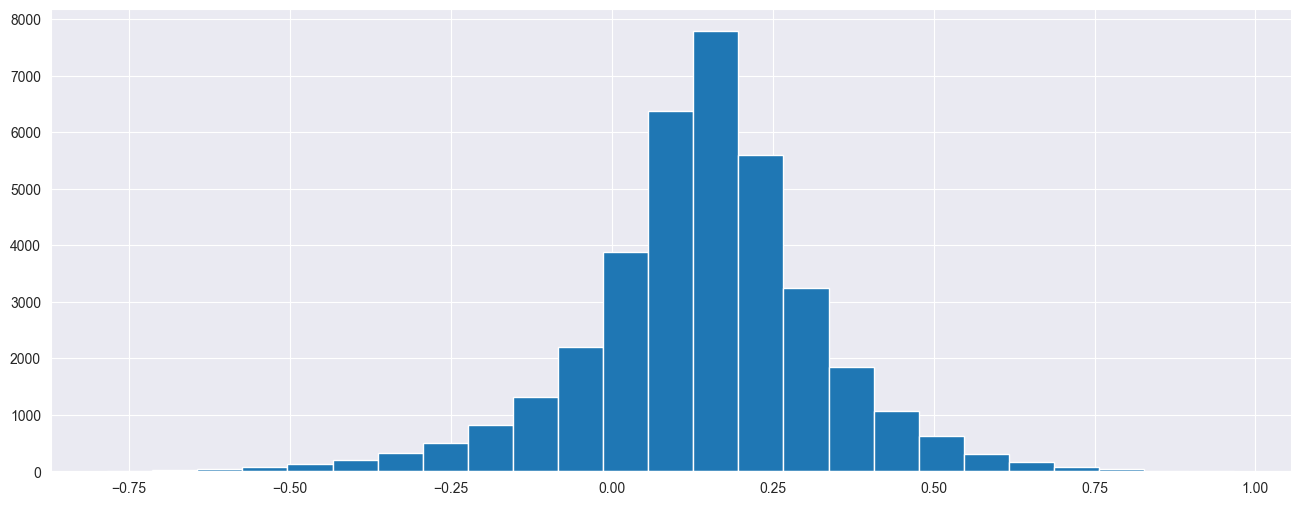

In [57]:
df_portfolios['return'].hist(bins=25);

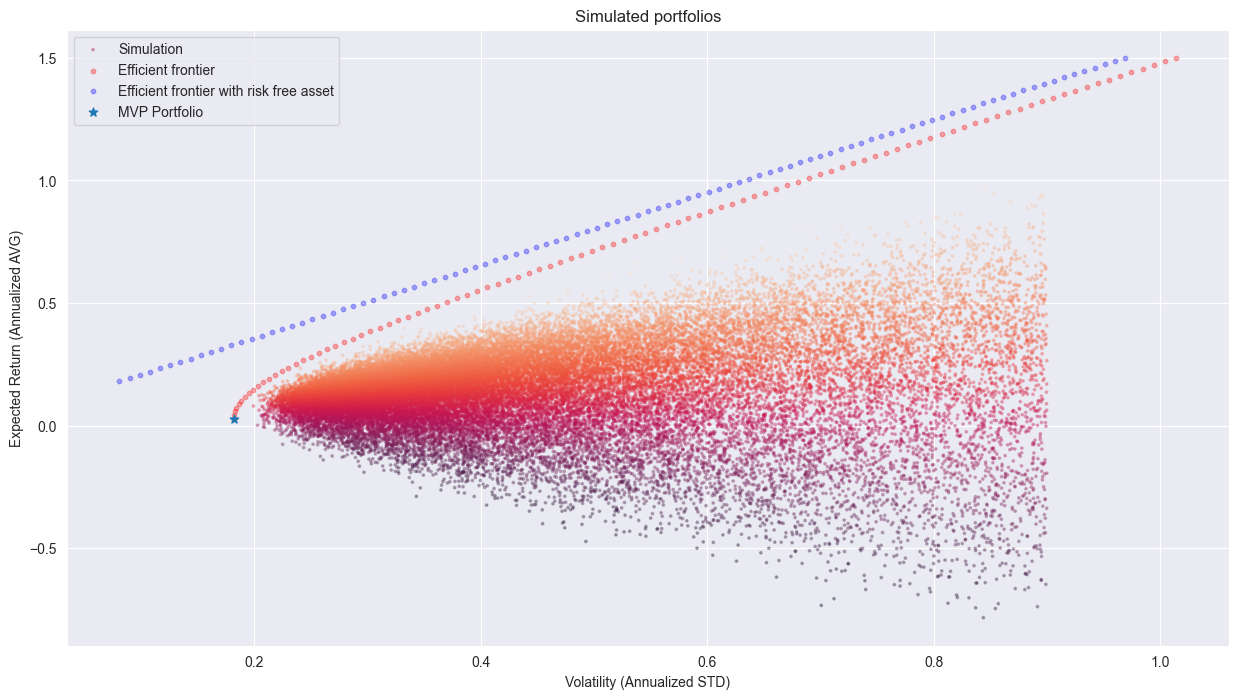

In [58]:
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)

ax1.scatter(df_portfolios['volatility'], df_portfolios['return'], s=3, c=df_portfolios['sharpe_ratio'], marker='o', label='Simulation', alpha=.3)
ax1.scatter(df_ef['volatility'], df_ef['return'], s=10, c='red', marker='o', label='Efficient frontier', alpha=.3)
ax1.scatter(df_ef_rf['volatility'], df_ef_rf['return'], s=10, c='blue', marker='o', label='Efficient frontier with risk free asset', alpha=.3)

ax1.scatter(volatility_mvp, return_mvp, s=40, marker='*', label='MVP Portfolio')

plt.xlabel('Volatility (Annualized STD)')
plt.ylabel('Expected Return (Annualized AVG)')
plt.title('Simulated portfolios')

plt.legend(loc='upper left')
plt.show();

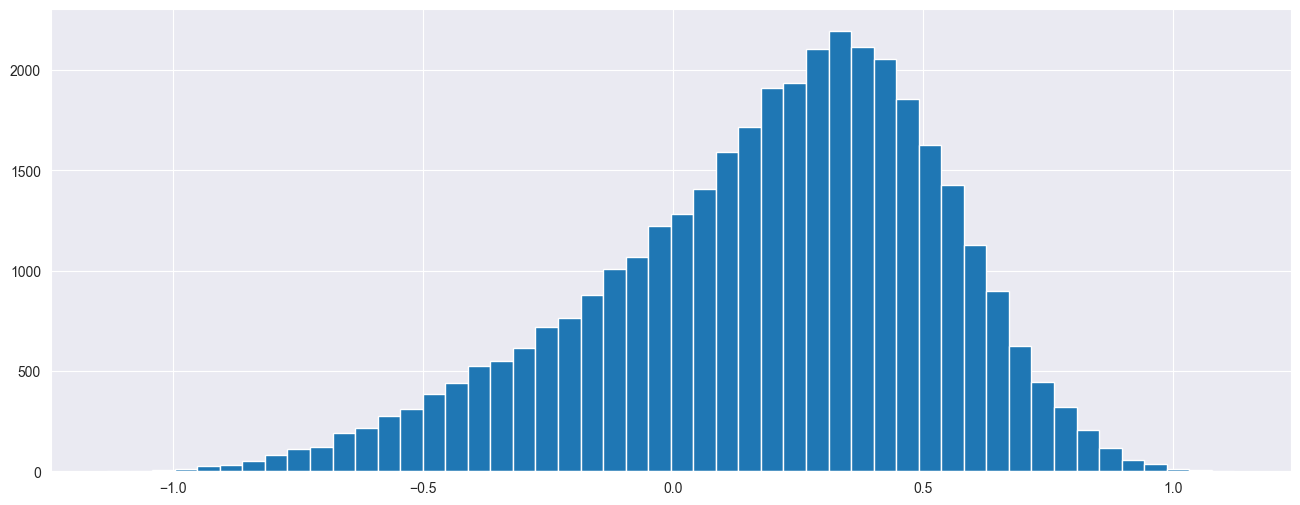

In [59]:
df_portfolios.sharpe_ratio.hist(bins=50);

# Tangency portfolio

In [60]:
def get_tangency_portfolio(covariance_matrix, expected_returns, risk_free_rate):
    # Calculate the inverse of the covariance matrix
    inverse_covariance_matrix = np.linalg.inv(covariance_matrix)
    
    # Calculate the vector of excess returns
    excess_returns = expected_returns - risk_free_rate
    
    # Calculate the numerator of the tangency portfolio weights
    numerator = np.dot(inverse_covariance_matrix, excess_returns)
    
    # Calculate the denominator of the tangency portfolio weights
    denominator = np.dot(np.dot(excess_returns, inverse_covariance_matrix), excess_returns)
    
    # Calculate the tangency portfolio weights
    tangency_weights = numerator / denominator
    
    return tangency_weights

In [61]:
# W_tg = compute_tangency_portfolio(
#     cov_ann, rf,avg_ann
# )

In [62]:
# def get_tangency_portfolio(Cov, E, rf):
#     inv_Cov = np.linalg.inv(Cov)
#     M_1 = np.zeros((Cov.shape[0],)) + 1 

#     num = inv_Cov @ (E - (rf * (np.zeros((Cov.shape[0],)) + 1) ))
#     den = M_1.T @ inv_Cov @ (E - (rf * (np.zeros((Cov.shape[0],)) + 1) ))

#     W_tg = num /den

#     return W_tg

In [63]:
W_tg = get_tangency_portfolio(cov_ann, avg_ann, rf)
W_tg

array([ 1.67093845, -0.4112039 ,  1.72492985,  0.06385967, -0.41359051,
        2.24332496,  0.60726703,  0.06995617,  0.26819852, -6.26721617])

In [64]:
return_tg = W_tg.T @ avg_ann
volatility_tg = (W_tg.T @ cov_ann @ W_tg)**0.5

print(f"Return tangency portfolio: {return_tg}")
print(f"Volatility tangency portfolio: {volatility_tg}")
print(f"Sharpe ratio: {(return_tg - rf)/volatility_tg}")

Return tangency portfolio: 0.973387844450479
Volatility tangency portfolio: 0.6729207149333227
Sharpe ratio: 1.3573483832207236


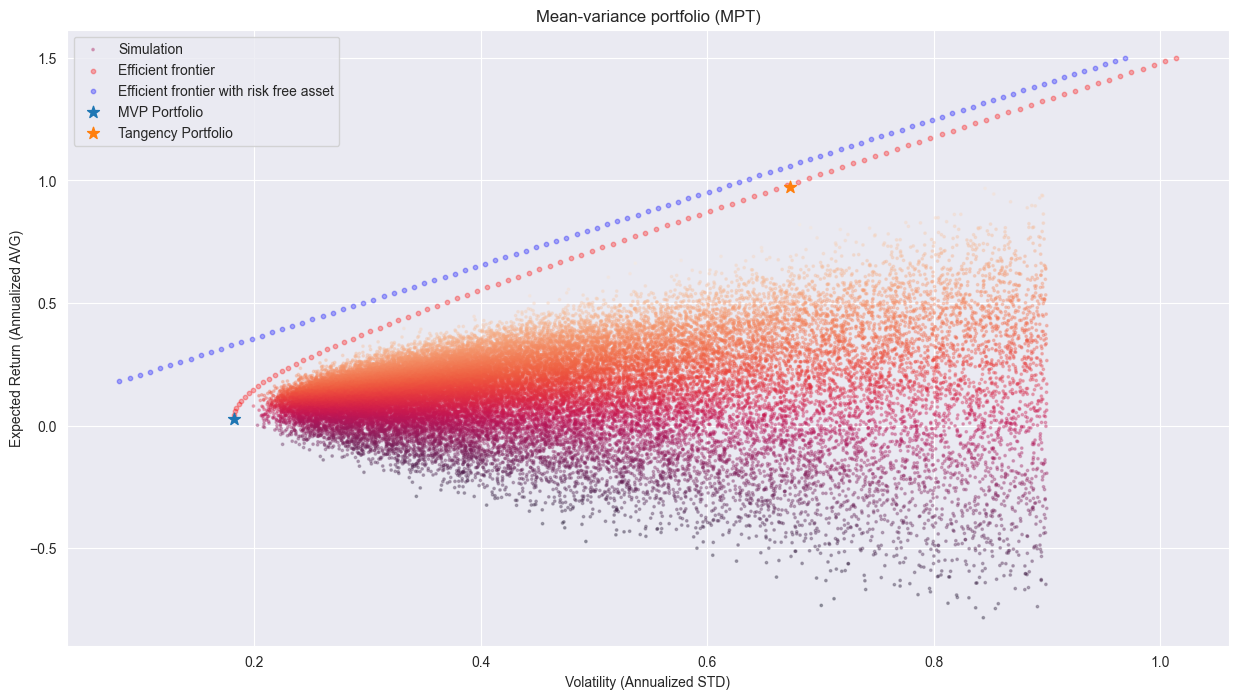

In [65]:
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)

ax1.scatter(df_portfolios['volatility'], df_portfolios['return'], s=3, c=df_portfolios['sharpe_ratio'], marker='o', label='Simulation', alpha=.3)
ax1.scatter(df_ef['volatility'], df_ef['return'], s=10, c='red', marker='o', label='Efficient frontier', alpha=.3)
ax1.scatter(df_ef_rf['volatility'], df_ef_rf['return'], s=10, c='blue', marker='o', label='Efficient frontier with risk free asset', alpha=.3)

ax1.scatter(volatility_mvp, return_mvp, s=80, marker='*', label='MVP Portfolio')
ax1.scatter(volatility_tg, return_tg, s=80, marker='*', label='Tangency Portfolio')

plt.xlabel('Volatility (Annualized STD)')
plt.ylabel('Expected Return (Annualized AVG)')
plt.title('Mean-variance portfolio (MPT)')

plt.legend(loc='upper left')
plt.show();

In [66]:
df_ef.max()

return                                                      1.5
volatility                                             1.014279
weights       [2.38, -0.7, 3.07, 0.08, -0.6, 3.19, 0.73, 0.3...
dtype: object

# Value at Risk (VaR)

## Parametric

In [67]:
initial_investment = 1000000
conf_level = 0.95

In [68]:
def VaR_parametric(initial_investment, conf_level):    
    alpha = norm.ppf(1 - conf_level, avg_daily, std_daily) 
    VaR_daily = (initial_investment - initial_investment * (1 + alpha))
    df_var = pd.DataFrame(
        {
            'stock':price_data.columns,
            'alpha':alpha,
            'daily_var':VaR_daily,
        }
    )
    return df_var

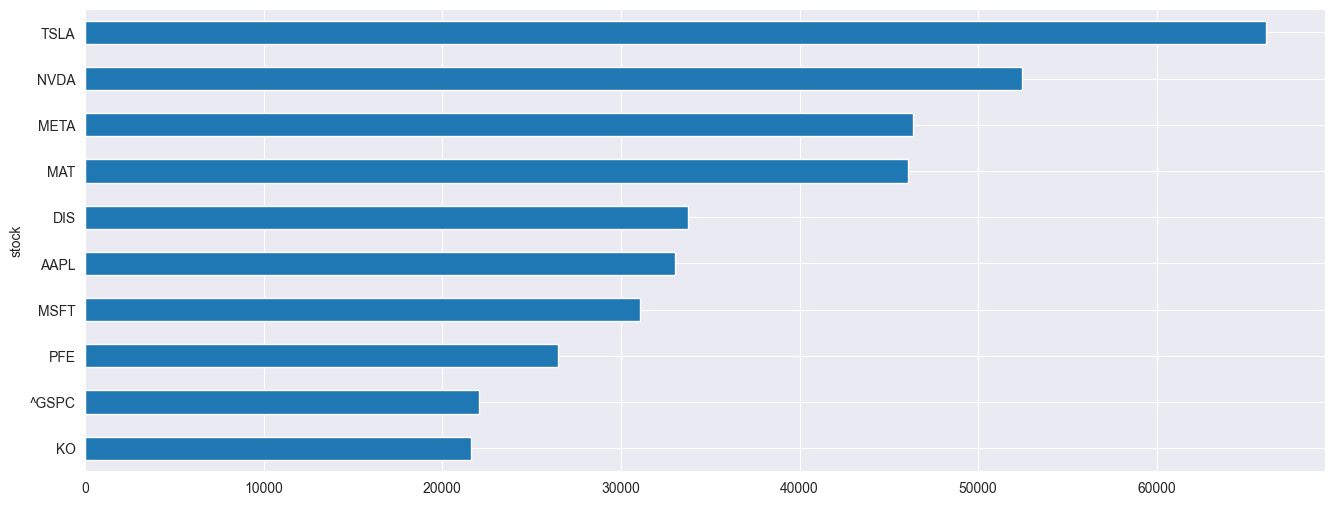

In [69]:
VaR_param = VaR_parametric(initial_investment, conf_level)
VaR_param.sort_values(
    by='daily_var'
).set_index(
    'stock'
).daily_var.plot(
    kind='barh'
);

In [70]:
VaR_param

,stock,alpha,daily_var
0,AAPL,-0.033042,33042.246167
1,DIS,-0.033780,33780.429523
2,KO,-0.021592,21591.917380
3,MAT,-0.046065,46064.555975
4,META,-0.046335,46334.837306
5,MSFT,-0.031085,31085.149965
6,NVDA,-0.052485,52484.928065
7,PFE,-0.026489,26489.177517
8,TSLA,-0.066137,66137.299208
9,^GSPC,-0.022037,22036.683852


In [71]:
df_var_horizons = pd.concat(
    [
        VaR_param.daily_var*np.sqrt(x) for x in range(1,31)
    ],axis=1
).T

df_var_horizons.columns = VaR_param.stock.to_list()

df_var_horizons = df_var_horizons.reset_index(drop=True)
df_var_horizons.index  = df_var_horizons.index + 1
df_var_horizons.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
1,33042.246167,33780.429523,21591.917380,46064.555975,46334.837306,31085.149965,52484.928065,26489.177517,66137.299208,22036.683852
2,46728.792660,47772.741574,30535.582396,65145.119805,65527.355328,43961.040669,74224.897090,37461.354101,93532.265518,31164.577173
3,57230.849157,58509.420235,37398.297935,79786.151377,80254.292374,53841.059100,90906.562040,45880.601310,114553.162503,38168.656062
4,66084.492333,67560.859046,43183.834759,92129.111950,92669.674611,62170.299930,104969.856130,52978.355034,132274.598415,44073.367704
5,73884.708558,75535.336722,48280.995026,103003.478514,103607.845942,69508.508413,117359.866948,59231.601596,147887.496876,49275.523092


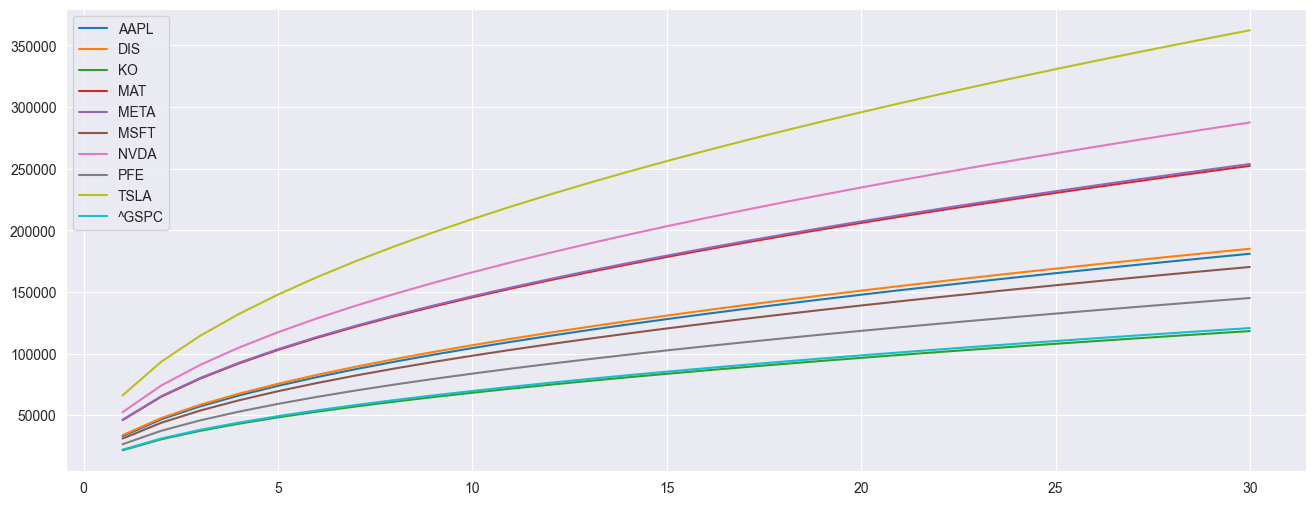

In [72]:
df_var_horizons.plot();

In [73]:
def calculate_portfolio_var(portfolio_value, weights, mean_returns, covariance_matrix, confidence_level):
    # Calculate the portfolio return
    portfolio_return = np.dot(weights, mean_returns)
    
    # Calculate the portfolio standard deviation
    portfolio_std_dev = np.sqrt(np.dot(np.dot(weights, covariance_matrix), weights.T))
    
    # Calculate the Z-score corresponding to the confidence level
    z_score = norm.ppf(1 - confidence_level)
    
    # Calculate the VaR
    portfolio_var = portfolio_value * (portfolio_return - z_score * portfolio_std_dev)
    
    return portfolio_var

In [74]:
calculate_portfolio_var(10000, W_mvp, avg_ann, cov_ann, .95)

3263.3179770442066